# INITIAL IMPORT

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import numpy as np
import gymnasium as gym
from src.config import Configuration


CONFIG = Configuration(
    n_training_episodes = 15_000,
    learning_rate = 0.7,
    n_eval_episodes = 1000,
    gym_id = "Taxi-v3",
    max_steps = 1000,
    gamma = 0.90,
    max_epsilon = 1.0,
    min_epsilon = 0.05,
    decay_rate = 0.001,
    use_rm = True, 
    use_crm = True, 
)

# LOAD ENV

In [3]:
env = gym.make(CONFIG.gym_id, render_mode="rgb_array")

state_space = env.observation_space.n
print("There are ", state_space, " possible states")
action_space = env.action_space.n
print("There are ", action_space, " possible actions")

There are  500  possible states
There are  6  possible actions


In [4]:
state, _ = env.reset()
# Returns a tuple: (taxi_row, taxi_col, passenger_location, destination)
taxi_row, taxi_col, passenger_location, destination = env.unwrapped.decode(state)

print(f"Taxi row: {taxi_row}")
print(f"Taxi column: {taxi_col}")
print(f"Passenger location: {passenger_location}")
print(f"Destination: {destination}")


Taxi row: 3
Taxi column: 2
Passenger location: 3
Destination: 0


# DEFINE Q-LEARNING

In [5]:
from src.models import RewardMachine
from src.envs import get_propositions

In [6]:
from src.models import QTable

In [7]:
from src.models import train_qtable

In [8]:
from src.models import evaluate_agent

# Generate and train

In [9]:
rm_taxi = RewardMachine(CONFIG, "rm_taxi.txt")
rm_taxi.states

{0: {(1, ('p',), 5.0)}, 1: {(1, ('!p',), -5.0), (2, ('p', 'd'), 20.0)}}

In [10]:
events = get_propositions(env, state)

rm_taxi.step(events)

(0, -1, False)

In [11]:
qt_taxi = QTable(CONFIG, env, rm_file="rm_taxi.txt" if CONFIG.use_rm else None)
qt_taxi = train_qtable(CONFIG, qt_taxi)

  0%|          | 0/15000 [00:00<?, ?it/s]

100%|██████████| 15000/15000 [00:03<00:00, 4512.65it/s]


In [12]:
mean_reward, std_reward = evaluate_agent(CONFIG, qt_taxi, get_propositions)
print(f"Mean_reward={mean_reward:.2f} +/- {std_reward:.2f}")

100%|██████████| 1000/1000 [00:00<00:00, 11818.77it/s]

Mean_reward=7.87 +/- 2.62


In [13]:
qt_taxi.Qtable

array([[[  0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ],
        [ -3.57094702,  -2.8566078 ,  -3.57094702,  -2.8566078 ,
          -2.06289756,  -2.8566078 ],
        [ -2.7485155 ,  -1.942795  ,  -2.7485155 ,  -1.942795  ,
          -1.04755   ,  -1.942795  ],
        ...,
        [ -1.04754312,  -0.7195    ,  -1.04728124,  -1.34252497,
          -1.01801367,  -1.04746875],
        [ -2.03486472,  -1.84766395,  -2.06050888,  -1.84766395,
          -2.06024387,  -2.03740609],
        [  0.05      ,  -0.355     ,   0.05      ,   0.5       ,
           0.05      ,   0.05      ]],

       [[  0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ],
        [-16.03094702, -12.2566078 , -16.03094702, -12.2566078 ,
          -8.06289756, -12.2566078 ],
        [-15.2085155 , -11.342795  , -15.2085155 , -11.342795  ,
          -7.04755   , -11.342795  ],
        ...,
        [ -7.04755   ,  -6.7195    ,  -7.0475

# Record video

In [15]:
from src.utils import record_video

record_video(CONFIG, qt_taxi, env, get_propositions, video_name="taxi_qtable_video.gif")

# Bench mark

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from src.config import Configuration
from src.models import QTable, evaluate_agent
from src.envs import get_propositions


def train_qtable_with_progress(config: Configuration, eval_every: int = 500):
    """Train and periodically evaluate to track learning evolution."""
    env = gym.make(config.gym_id, render_mode="rgb_array")
    qtable = QTable(config, env, rm_file="rm_taxi.txt" if config.use_rm else None)

    iterations = []
    eval_means = []
    eval_stds = []

    for episode in tqdm(range(config.n_training_episodes), desc=f"RM={config.use_rm}, CRM={config.use_crm}"):
        epsilon = config.min_epsilon + (config.max_epsilon - config.min_epsilon) * np.exp(-config.decay_rate * episode)
        state, _ = env.reset()
        qtable.reset_rm()

        terminated, truncated = False, False
        for _ in range(config.max_steps):
            action = qtable.epsilon_greedy_policy(state, epsilon, env)
            new_state, env_reward, terminated, truncated, _ = env.step(action)

            rm_done = qtable.update(
                state,
                action,
                env_reward,
                new_state,
                config.gamma,
                config.learning_rate,
                env,
                use_crm=config.use_crm,
            )

            if terminated or truncated or rm_done:
                break

            state = new_state

        if (episode + 1) % eval_every == 0 or episode == 0:
            mean_reward, std_reward = evaluate_agent(config, qtable, get_propositions)
            iterations.append(episode + 1)
            eval_means.append(mean_reward)
            eval_stds.append(std_reward)

    env.close()
    return qtable, np.array(iterations), np.array(eval_means), np.array(eval_stds)


def convergence_iteration(iterations, values, smooth_window=3, plateau_ratio=0.95, patience=3):
    """Estimate convergence as first iteration that reaches and maintains near-plateau performance."""
    if len(values) == 0:
        return None

    if len(values) < smooth_window:
        smoothed = values
        smooth_iters = iterations
    else:
        kernel = np.ones(smooth_window) / smooth_window
        smoothed = np.convolve(values, kernel, mode="valid")
        smooth_iters = iterations[smooth_window - 1:]

    best = np.max(smoothed)
    threshold = best - (1.0 - plateau_ratio) * max(1.0, abs(best))

    if len(smoothed) < patience:
        return int(smooth_iters[np.argmax(smoothed)])

    for i in range(len(smoothed) - patience + 1):
        if np.all(smoothed[i : i + patience] >= threshold):
            return int(smooth_iters[i])

    return int(smooth_iters[np.argmax(smoothed)])


# Shared benchmark settings
base_kwargs = dict(
    n_training_episodes=15_000,
    learning_rate=0.7,
    n_eval_episodes=200,
    gym_id="Taxi-v3",
    max_steps=1000,
    gamma=0.90,
    max_epsilon=1.0,
    min_epsilon=0.05,
    decay_rate=0.001,
)

variants = [
    {"label": "No RM / No CRM", "use_rm": False, "use_crm": False},
    {"label": "RM / No CRM", "use_rm": True, "use_crm": False},
    {"label": "RM / CRM", "use_rm": True, "use_crm": True},
]

results = {}

for variant in variants:
    cfg = Configuration(
        **base_kwargs,
        use_rm=variant["use_rm"],
        use_crm=variant["use_crm"],
    )

    _, iters, means, stds = train_qtable_with_progress(cfg, eval_every=500)
    conv_it = convergence_iteration(iters, means, smooth_window=3, plateau_ratio=0.95, patience=3)

    results[variant["label"]] = {
        "iterations": iters,
        "mean_rewards": means,
        "std_rewards": stds,
        "convergence_iteration": conv_it,
    }

# Print convergence summary
for label, data in results.items():
    print(f"{label:15s} -> estimated convergence at episode {data['convergence_iteration']}")

# Plot evolution
plt.figure(figsize=(12, 6))
for label, data in results.items():
    x = data["iterations"]
    y = data["mean_rewards"]
    s = data["std_rewards"]

    plt.plot(x, y, marker="o", linewidth=2, label=label)
    plt.fill_between(x, y - s, y + s, alpha=0.12)

plt.title("Q-Learning Benchmark: Reward Evolution vs Training Episodes")
plt.xlabel("Training episodes")
plt.ylabel("Evaluation mean reward")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Human playing

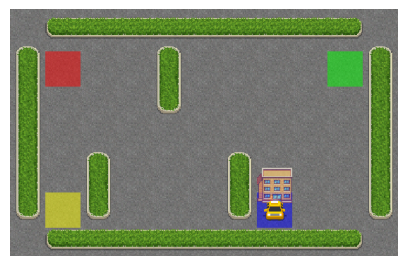

Action: 5 | Reward: -10
Row: 4, Col: 3, P_Loc: 3, Dest: 3


In [ ]:
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import clear_output

# 1. Initialize with rgb_array for visual frames
if 'env' not in globals():
    env = gym.make("Taxi-v3", render_mode="rgb_array")
    state, _ = env.reset()

# --- HUMAN PLAY ---
# 0=South, 1=North, 2=East, 3=West, 4=Pickup, 5=Dropoff
my_action = 5
# ------------------

# Step the simulation
state, reward, terminated, truncated, _ = env.step(my_action)

# 2. Get the single frame
img = env.render()

# 3. Visualize
clear_output(wait=True)
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis('off')
plt.show()

# Data output
taxi_row, taxi_col, p_loc, dest = env.unwrapped.decode(state)
print(f"Action: {my_action} | Reward: {reward}")
print(f"Row: {taxi_row}, Col: {taxi_col}, P_Loc: {p_loc}, Dest: {dest}")

if terminated or truncated:
    print("Goal reached or Resetting...")
    state, _ = env.reset()